# One-node Reservoir

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
import struct
from array import array
from os.path  import join
import time

np.set_printoptions(threshold=np.inf)
rng = np.random.default_rng(seed=42)

In [2]:
THRESHOLD_VOLTAGE = 0
SCALE_VOLTAGE = 11
VOLTAGE = 2.5
CURVATURE = 1

IMAGE_THRESHOLD = 60

TIME_RESOLUTION = 0.2
BETA = 0.56
TAU = 2.6 #ms
K = 700 #nA

# TIME_RESOLUTION = 0.2
# K = 400
# BETA = 0.65
# TAU = 3.00

NEURON_COUNT = 1

TRAIN_BATCH_SIZE = 6000
TEST_BATCH_SIZE = 1000

MAX_ITERATION = 20
LEARNING_RATE = 2

In [3]:
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)

In [4]:
input_path = 'MNIST'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)

(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

In [5]:
def image_to_pulses_old(img, threshold=IMAGE_THRESHOLD, interval=2):
    pulse_train = img.flatten()

    pulse_train = (pulse_train > threshold).astype(np.uint8)
    # pulse_train = (pulse_train / 255 * SCALE_VOLTAGE).astype(np.float16)

    zeros = np.zeros(interval * len(pulse_train), dtype=np.uint8)
    zeros[::interval] = pulse_train
    pulse_train = zeros

    pulse_train = pulse_train.reshape((28, 28*interval)).T

    return pulse_train

def image_to_pulses(img, threshold=IMAGE_THRESHOLD, interval=2):
    pulse_train = img.flatten()

    pulse_train = (pulse_train > threshold).astype(np.uint8)

    pulse_train = pulse_train.reshape((28, 28))[::2, :].flatten()

    zeros = np.zeros(interval * len(pulse_train), dtype=np.uint8)
    zeros[::interval] = pulse_train
    pulse_train = zeros

    pulse_train = pulse_train.reshape((98, 8))

    return pulse_train

def get_images_batch(batch_size = 600, x=x_train, y=y_train):
    random_idx = rng.choice(len(x), size=batch_size, replace=False)

    x_batch = x[random_idx]
    y_batch = y[random_idx]

    return x_batch, y_batch

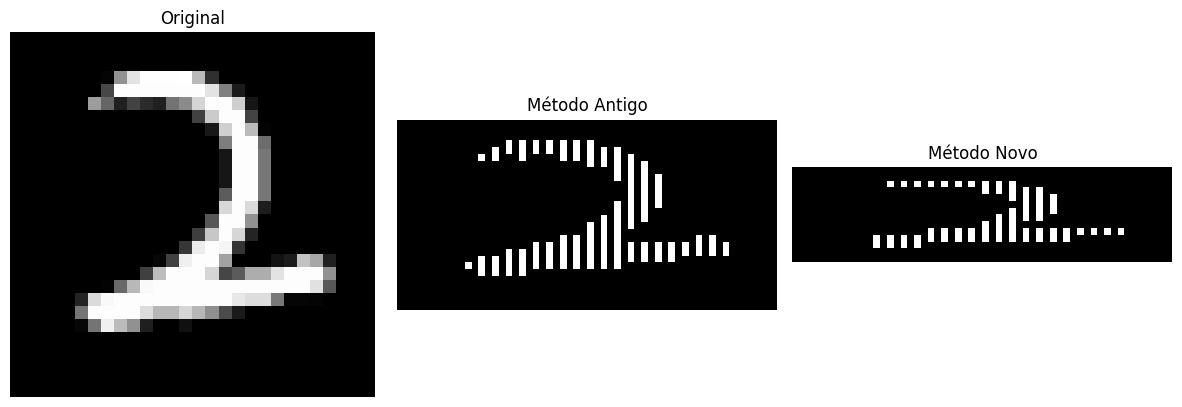

In [6]:
idx = np.random.randint(0, 60000)

# Cria uma figura com 1 linha e 3 colunas
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 1ª Imagem: Original
axes[0].imshow(x_train[idx], cmap="binary_r")
axes[0].set_title("Original")
axes[0].axis("off")  # Opcional: remove as bordas com números dos eixos

# 2ª Imagem: Método Antigo
axes[1].imshow(image_to_pulses_old(x_train[idx], interval=2).T, cmap="binary_r")
axes[1].set_title("Método Antigo")
axes[1].axis("off")

# 3ª Imagem: Método Novo
axes[2].imshow(image_to_pulses(x_train[idx], interval=2).reshape(14, 56), cmap="binary_r")
axes[2].set_title("Método Novo")
axes[2].axis("off")

# Ajusta o espaçamento para não cortar os títulos e exibe
plt.tight_layout()
plt.show()

In [7]:
def create_pulse_train(basic_voltage, pulse_voltage, pulse_duration, interval_duration, pulse_quantity):
    train_length = (pulse_duration + interval_duration) * pulse_quantity

    pulse_train = np.zeros(train_length) + basic_voltage

    for i in range(pulse_quantity):
        pulse_train[i * (pulse_duration + interval_duration): (i * (pulse_duration + interval_duration)) + (pulse_duration)] = pulse_voltage
    
    return pulse_train

def evolve_IGT(k, v, In_1, beta, tau, threshold_voltage=THRESHOLD_VOLTAGE, scale_voltage=SCALE_VOLTAGE, curvature=CURVATURE):
    current_in_infinity = (k * (1 - np.exp(-((v - threshold_voltage) / scale_voltage) ** curvature)))

    return current_in_infinity + (In_1 - current_in_infinity) * np.exp(-(TIME_RESOLUTION / tau) ** beta)

def plot_out_current(pulse_train, out_current, title, ranges):
    time = np.arange(len(out_current)) * TIME_RESOLUTION

    _, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(6, 4),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 3]}
    )

    # Pulse train
    ax1.step(time, pulse_train, where="post")
    ax1.set_ylabel("Pulse")
    ax1.set_title(title)
    ax1.grid(True)

    # Out Current
    ax2.plot(time, out_current)
    ax2.scatter(time, out_current, facecolors="none", edgecolors="tab:blue")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel(r"$I_{DS}\ (nA)$")
    ax2.grid(True)
    if ranges != ((0,0),(0,0)):
        ax2.set_xlim(ranges[0])
        ax2.set_ylim(ranges[1])

    plt.tight_layout()
    plt.show()

def generate_out_current(pulse_train, k, beta, tau, plot=False, title="", ranges=((0,0),(0,0))):
    
    out_current = np.zeros_like(pulse_train)

    for i in range(1, len(out_current)):
        out_current[i] = evolve_IGT(k, pulse_train[i], out_current[i-1], beta, tau)

    if plot:
        plot_out_current(pulse_train, out_current, title, ranges)


    return out_current

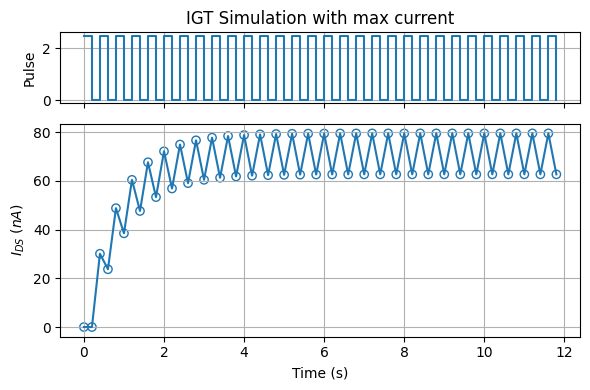

In [8]:
max_pulse = create_pulse_train(0, VOLTAGE, 1, 1, 30)

max_current = np.max(generate_out_current(max_pulse, K, BETA, TAU, True, "IGT Simulation with max current"))

In [22]:
def run_reservoir(images):
    reconstructed_images_reservoir = []
    reconstructed_images = []

    for i, img in enumerate(images):
        img_pulses = image_to_pulses(img)

        new_img = []
        
        for pulse in img_pulses:
            out_current = generate_out_current(pulse, K, BETA, TAU)
            new_img.append(out_current[-1] / max_current)

        new_img = np.array(new_img)
        downscaled_img = (np.array(images[i]) > IMAGE_THRESHOLD).astype(np.uint8)[::2, ::4].flatten()

        reconstructed_images_reservoir.append(new_img)
        reconstructed_images.append(downscaled_img)
    
    return reconstructed_images_reservoir, reconstructed_images

In [23]:
from sklearn.neural_network import MLPClassifier

In [24]:
images, labels = get_images_batch(TRAIN_BATCH_SIZE)
reconstructed_images_reservoir, reconstructed_images = run_reservoir(images)

model_reservoir = MLPClassifier(
    hidden_layer_sizes=(),
    activation="logistic",
    solver="sgd",
    learning_rate="constant",
    learning_rate_init=2.0,
    batch_size=600,
    max_iter=20,
    random_state=42
)

model_reservoir.fit(reconstructed_images_reservoir, labels)

model = MLPClassifier(
    hidden_layer_sizes=(),
    activation="logistic",
    solver="sgd",
    learning_rate="constant",
    learning_rate_init=2.0,
    batch_size=600,
    max_iter=20,
    random_state=42
)

model.fit(reconstructed_images, labels)

C:\Users\filipi2610041\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\filipi2610041\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.",()
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'logistic'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",600
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",2.0
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",20
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


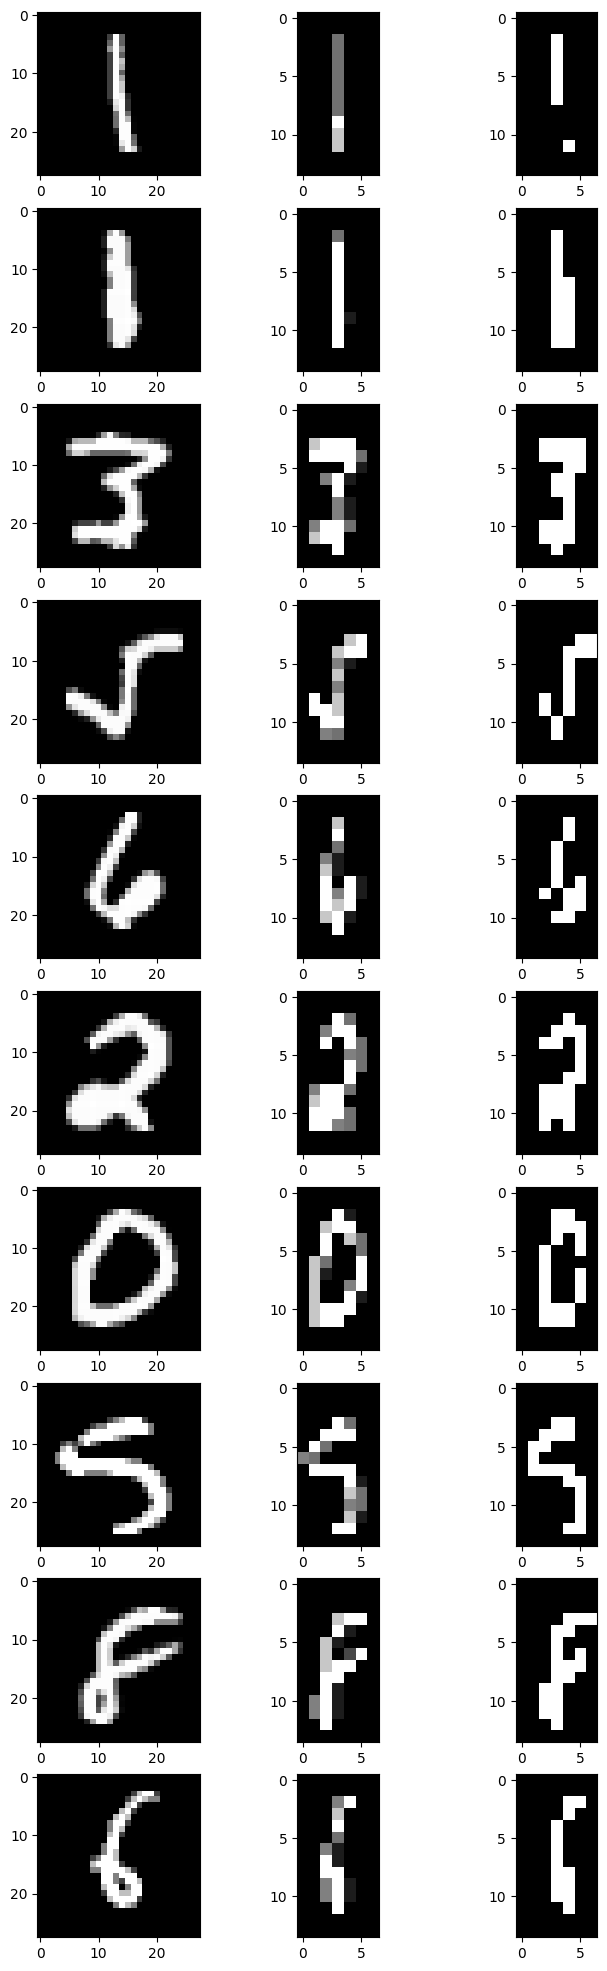

In [31]:
fig, axes = plt.subplots(len(reconstructed_images_reservoir[:10]), 3, figsize=(8, 2.5*len(reconstructed_images_reservoir[:10])))

for i, img in enumerate(reconstructed_images_reservoir[:10]):
    axes[i, 0].imshow(images[i], cmap="binary_r")

    axes[i, 1].imshow(img.reshape(14,7), cmap="binary_r")

    axes[i, 2].imshow(reconstructed_images[i].reshape(14,7), cmap="binary_r")

# plt.tight_layout()
# plt.show()

In [26]:
images_test, labels_test = get_images_batch(TEST_BATCH_SIZE, x_test, y_test)
reconstructed_test_images_reservoir, reconstructed_test_images = run_reservoir(images_test)

accuracy_reservoir = model.score(reconstructed_test_images_reservoir, labels_test)
accuracy = model.score(reconstructed_test_images, labels_test)

print(f"Accuracy w/ Reservoir  : {(100*accuracy_reservoir):2f}%")
print(f"Accuracy wo/ Reservoir : {(100*accuracy):2f}%")

Accuracy w/ Reservoir  : 12.800000%
Accuracy wo/ Reservoir : 81.300000%
